In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [171]:
data =pd.read_csv('dataset\house_price_extreme_messy_15654_rows.csv')
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\h'
C:\Users\KIIT\AppData\Local\Temp\ipykernel_8224\1454765004.py:1: SyntaxWarning: invalid escape sequence '\h'
  data =pd.read_csv('dataset\house_price_extreme_messy_15654_rows.csv')


,House_ID,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,Owner_Name,...,Email,Property_Type,Furnished,Floor_No,Total_Floors,Latitude,Longitude,Loan_Status,Registration_Price,Notes
0,H5239,2020/02/21,Bhubaneshwar,1503,1,4,Yes,1981,5.7M,Pooja,...,pooja#gmail.com,Flat,N,Ground,5,20.3094,85.5065,Approved,13712835,Suspicious price
1,H2788,2020-11-14,Bhubaneshwar,918,3,1,No,2014,8350753,Rakesh,...,rakesh@outlook.com,Apartment,No,2,2,20.3553,86.3665,Pending,6663623,Suspicious price
2,H5208,29/11/20,Bhubaneshwar,1358,Two,2,N,1995,9.8M,Meena,...,meena@gmail.com,Apartment,Y,3,5,19.5662,86.4131,Rejected,14044602,Old house
3,H1742,2022/03/21,Cuttack,1085,Three,4,N,2028,5679591,Arun,...,arun@gmail.com,Flat,N,Ground,2,19.8848,86.0959,Pending,10877065,Old house
4,H4533,2023/10/25,Bhubaneswar,3292,1,3,No,2028,2054447,Rajesh,...,rajesh@outlook.com,APT,No,1,6,20.2625,86.0394,Rejected,2009594,NaN


In [172]:
data.info()
data.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15654 entries, 0 to 15653
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   House_ID            15654 non-null  object 
 1   Date_Sold           15654 non-null  object 
 2   City                15654 non-null  object 
 3   Area_sqft           15599 non-null  object 
 4   Bedrooms            15654 non-null  object 
 5   Bathrooms           15654 non-null  int64  
 6   Garage              15654 non-null  object 
 7   Year_Built          15654 non-null  int64  
 8   Price               15578 non-null  object 
 9   Owner_Name          15654 non-null  object 
 10  Contact             15654 non-null  object 
 11  Email               15654 non-null  object 
 12  Property_Type       15654 non-null  object 
 13  Furnished           15654 non-null  object 
 14  Floor_No            15654 non-null  object 
 15  Total_Floors        15654 non-null  int64  
 16  Lati

,House_ID,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,Owner_Name,...,Email,Property_Type,Furnished,Floor_No,Total_Floors,Latitude,Longitude,Loan_Status,Registration_Price,Notes
15649,H2162,12/07/22,Puri,2004,Two,3,Yes,2018,9.1M,Unknown,...,unknown@gmail.com,APT,No,3,5,20.4786,85.5982,Pending,3388721,Old house
15650,H4306,2021-11-01,Bhubaneshwar,2950,4,4,No,2028,12639088,Amit,...,amit@gmail,Apartment,Yes,1,10,20.2159,86.4082,Rejected,10676143,Suspicious price
15651,H4935,2022-04-30,Puri,2377,2,1,YES,2028,6806979,Pooja,...,pooja@gmail.com,Villa,No,2,10,20.2710,86.3315,Pending,7258609,Old house
15652,H1478,2020-04-02,BBSR,980,1,3,Y,1993,14.4M,Amit,...,amit@gmail,Villa,No,2,6,20.1363,86.0574,Approved,7512664,Good property
15653,H0928,2020-06-27,Khordha,2456,2,1,YES,1988,6474127,Amit,...,amit@gmail.com,House,No,2,5,20.2862,85.8813,Rejected,3894953,Suspicious price


In [173]:
data.shape
data.columns

Index(['House_ID', 'Date_Sold', 'City', 'Area_sqft', 'Bedrooms', 'Bathrooms',
       'Garage', 'Year_Built', 'Price', 'Owner_Name', 'Contact', 'Email',
       'Property_Type', 'Furnished', 'Floor_No', 'Total_Floors', 'Latitude',
       'Longitude', 'Loan_Status', 'Registration_Price', 'Notes'],
      dtype='object')

In [174]:
data.rename(columns={'House_ID':'HouseID', 'Owner_Name': 'OwnerName'}, inplace = True)


In [175]:
data

,HouseID,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,OwnerName,...,Email,Property_Type,Furnished,Floor_No,Total_Floors,Latitude,Longitude,Loan_Status,Registration_Price,Notes
0,H5239,2020/02/21,Bhubaneshwar,1503,1,4,Yes,1981,5.7M,Pooja,...,pooja#gmail.com,Flat,N,Ground,5,20.3094,85.5065,Approved,13712835,Suspicious price
1,H2788,2020-11-14,Bhubaneshwar,918,3,1,No,2014,8350753,Rakesh,...,rakesh@outlook.com,Apartment,No,2,2,20.3553,86.3665,Pending,6663623,Suspicious price
2,H5208,29/11/20,Bhubaneshwar,1358,Two,2,N,1995,9.8M,Meena,...,meena@gmail.com,Apartment,Y,3,5,19.5662,86.4131,Rejected,14044602,Old house
3,H1742,2022/03/21,Cuttack,1085,Three,4,N,2028,5679591,Arun,...,arun@gmail.com,Flat,N,Ground,2,19.8848,86.0959,Pending,10877065,Old house
4,H4533,2023/10/25,Bhubaneswar,3292,1,3,No,2028,2054447,Rajesh,...,rajesh@outlook.com,APT,No,1,6,20.2625,86.0394,Rejected,2009594,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15649,H2162,12/07/22,Puri,2004,Two,3,Yes,2018,9.1M,Unknown,...,unknown@gmail.com,APT,No,3,5,20.4786,85.5982,Pending,3388721,Old house
15650,H4306,2021-11-01,Bhubaneshwar,2950,4,4,No,2028,12639088,Amit,...,amit@gmail,Apartment,Yes,1,10,20.2159,86.4082,Rejected,10676143,Suspicious price
15651,H4935,2022-04-30,Puri,2377,2,1,YES,2028,6806979,Pooja,...,pooja@gmail.com,Villa,No,2,10,20.2710,86.3315,Pending,7258609,Old house
15652,H1478,2020-04-02,BBSR,980,1,3,Y,1993,14.4M,Amit,...,amit@gmail,Villa,No,2,6,20.1363,86.0574,Approved,7512664,Good property


In [176]:
data.dtypes

HouseID                object
Date_Sold              object
City                   object
Area_sqft              object
Bedrooms               object
Bathrooms               int64
Garage                 object
Year_Built              int64
Price                  object
OwnerName              object
Contact                object
Email                  object
Property_Type          object
Furnished              object
Floor_No               object
Total_Floors            int64
Latitude              float64
Longitude             float64
Loan_Status            object
Registration_Price      int64
Notes                  object
dtype: object

In [177]:
data.describe()

,Bathrooms,Year_Built,Total_Floors,Latitude,Longitude,Registration_Price
count,15654.000000,15654.000000,15654.000000,15654.000000,15654.000000,1.565400e+04
mean,2.490290,2015.409799,8.021656,20.001870,85.997432,8.534412e+06
std,1.120596,15.799449,4.308147,0.288759,0.288138,3.742937e+06
min,1.000000,1980.000000,1.000000,19.500100,85.500200,2.000402e+06
25%,1.000000,2003.000000,4.000000,19.755000,85.749500,5.295635e+06
50%,2.000000,2028.000000,8.000000,20.002050,85.997400,8.568411e+06
75%,3.000000,2028.000000,12.000000,20.253275,86.246500,1.181919e+07
max,4.000000,2028.000000,15.000000,20.500000,86.500000,1.499864e+07


In [178]:
data.describe(include='object')

,HouseID,Date_Sold,City,Area_sqft,Bedrooms,Garage,Price,OwnerName,Contact,Email,Property_Type,Furnished,Floor_No,Loan_Status,Notes
count,15654,15654,15654,15599,15654,15654,15578,15654,15654,15654,15654,15654,15654,15654,9360
unique,6782,5560,6,5243,6,5,11762,9,5322,45,5,4,6,3,3
top,H0202,06/02/25,Bhubaneswar,One Thousand,Three,Y,4.3M,Amit,0000000000,amit@gmail,House,Yes,3,Rejected,Good property
freq,9,12,2686,25,2678,3191,41,1824,5231,634,3252,3981,2636,5226,3164


In [179]:
data.isnull().sum()

HouseID                  0
Date_Sold                0
City                     0
Area_sqft               55
Bedrooms                 0
Bathrooms                0
Garage                   0
Year_Built               0
Price                   76
OwnerName                0
Contact                  0
Email                    0
Property_Type            0
Furnished                0
Floor_No                 0
Total_Floors             0
Latitude                 0
Longitude                0
Loan_Status              0
Registration_Price       0
Notes                 6294
dtype: int64

In [180]:
data.duplicated().sum()
data['Notes']

0        Suspicious price
1        Suspicious price
2               Old house
3               Old house
4                     NaN
               ...       
15649           Old house
15650    Suspicious price
15651           Old house
15652       Good property
15653    Suspicious price
Name: Notes, Length: 15654, dtype: object

In [181]:
data['Notes'].isnull().sum()/len(data['Notes'])*100

np.float64(40.20697585281717)

In [182]:
data.drop('Notes',axis=1,inplace=True)

In [183]:
data.drop(['OwnerName','Contact','Email'],axis=1,inplace=True)
data

,HouseID,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,Property_Type,Furnished,Floor_No,Total_Floors,Latitude,Longitude,Loan_Status,Registration_Price
0,H5239,2020/02/21,Bhubaneshwar,1503,1,4,Yes,1981,5.7M,Flat,N,Ground,5,20.3094,85.5065,Approved,13712835
1,H2788,2020-11-14,Bhubaneshwar,918,3,1,No,2014,8350753,Apartment,No,2,2,20.3553,86.3665,Pending,6663623
2,H5208,29/11/20,Bhubaneshwar,1358,Two,2,N,1995,9.8M,Apartment,Y,3,5,19.5662,86.4131,Rejected,14044602
3,H1742,2022/03/21,Cuttack,1085,Three,4,N,2028,5679591,Flat,N,Ground,2,19.8848,86.0959,Pending,10877065
4,H4533,2023/10/25,Bhubaneswar,3292,1,3,No,2028,2054447,APT,No,1,6,20.2625,86.0394,Rejected,2009594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15649,H2162,12/07/22,Puri,2004,Two,3,Yes,2018,9.1M,APT,No,3,5,20.4786,85.5982,Pending,3388721
15650,H4306,2021-11-01,Bhubaneshwar,2950,4,4,No,2028,12639088,Apartment,Yes,1,10,20.2159,86.4082,Rejected,10676143
15651,H4935,2022-04-30,Puri,2377,2,1,YES,2028,6806979,Villa,No,2,10,20.2710,86.3315,Pending,7258609
15652,H1478,2020-04-02,BBSR,980,1,3,Y,1993,14.4M,Villa,No,2,6,20.1363,86.0574,Approved,7512664


In [184]:
data['Date_Sold'].dtypes
data['Date_Sold'] = pd.to_datetime(data['Date_Sold'],format='mixed', errors='coerce')

In [185]:
data['Day'] = data['Date_Sold'].dt.day

In [186]:
data['Month'] = data['Date_Sold'].dt.month

In [187]:
data['Sold_Year'] = data['Date_Sold'].dt.year

In [188]:
data['Area_sqft'].unique()

array(['1503', '918', '1358', ..., '2928 sqft', '609', '1815 sqft'],
      dtype=object)

In [189]:
data['Area_sqft'] = data['Area_sqft'].str.extract(r'(\d+)')

In [190]:
data['Area_sqft'].astype(float).isnull().sum()/len(data['Area_sqft'])*100

np.float64(0.5110514884374601)

<Axes: xlabel='Area_sqft', ylabel='Count'>

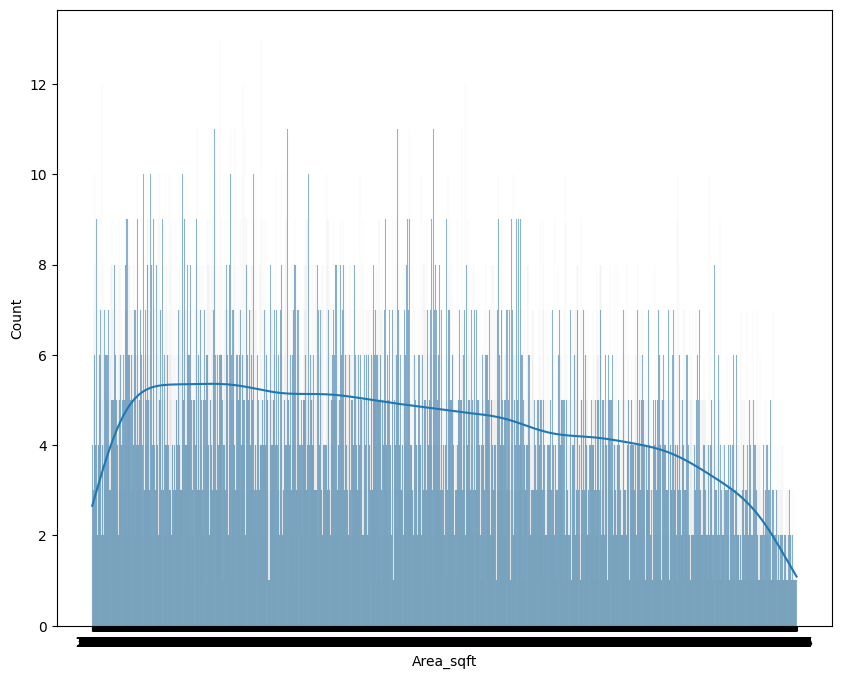

In [191]:
plt.figure(figsize=(10,8))
sns.histplot(data['Area_sqft'].dropna(),kde=True,bins=100)
# kde = kernel density estimation, it gives us the smoothed curve of the distribution of the data

In [192]:
# # 1) Extract numbers
# data['Area_sqft'] = data['Area_sqft'].str.extract(r'(\d+)')

# # 2) Convert to numeric (VERY IMPORTANT)
data['Area_sqft'] = pd.to_numeric(data['Area_sqft'], errors='coerce')

# # 3) Fill missing values with median
data['Area_sqft'] = data['Area_sqft'].fillna(data['Area_sqft'].median()).astype(float)

In [193]:
data

,HouseID,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,Property_Type,Furnished,Floor_No,Total_Floors,Latitude,Longitude,Loan_Status,Registration_Price,Day,Month,Sold_Year
0,H5239,2020-02-21,Bhubaneshwar,1503.0,1,4,Yes,1981,5.7M,Flat,N,Ground,5,20.3094,85.5065,Approved,13712835,21,2,2020
1,H2788,2020-11-14,Bhubaneshwar,918.0,3,1,No,2014,8350753,Apartment,No,2,2,20.3553,86.3665,Pending,6663623,14,11,2020
2,H5208,2020-11-29,Bhubaneshwar,1358.0,Two,2,N,1995,9.8M,Apartment,Y,3,5,19.5662,86.4131,Rejected,14044602,29,11,2020
3,H1742,2022-03-21,Cuttack,1085.0,Three,4,N,2028,5679591,Flat,N,Ground,2,19.8848,86.0959,Pending,10877065,21,3,2022
4,H4533,2023-10-25,Bhubaneswar,3292.0,1,3,No,2028,2054447,APT,No,1,6,20.2625,86.0394,Rejected,2009594,25,10,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15649,H2162,2022-12-07,Puri,2004.0,Two,3,Yes,2018,9.1M,APT,No,3,5,20.4786,85.5982,Pending,3388721,7,12,2022
15650,H4306,2021-11-01,Bhubaneshwar,2950.0,4,4,No,2028,12639088,Apartment,Yes,1,10,20.2159,86.4082,Rejected,10676143,1,11,2021
15651,H4935,2022-04-30,Puri,2377.0,2,1,YES,2028,6806979,Villa,No,2,10,20.2710,86.3315,Pending,7258609,30,4,2022
15652,H1478,2020-04-02,BBSR,980.0,1,3,Y,1993,14.4M,Villa,No,2,6,20.1363,86.0574,Approved,7512664,2,4,2020


In [194]:
data['Bedrooms'].unique()

array(['1', '3', 'Two', 'Three', '2', '4'], dtype=object)

In [195]:
data['Bedrooms'] = data['Bedrooms'].replace('Two',2)
data['Bedrooms'] = data['Bedrooms'].replace('Three',3)
data['Bedrooms'] = data['Bedrooms'].astype(int)

In [196]:
data

,HouseID,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,Property_Type,Furnished,Floor_No,Total_Floors,Latitude,Longitude,Loan_Status,Registration_Price,Day,Month,Sold_Year
0,H5239,2020-02-21,Bhubaneshwar,1503.0,1,4,Yes,1981,5.7M,Flat,N,Ground,5,20.3094,85.5065,Approved,13712835,21,2,2020
1,H2788,2020-11-14,Bhubaneshwar,918.0,3,1,No,2014,8350753,Apartment,No,2,2,20.3553,86.3665,Pending,6663623,14,11,2020
2,H5208,2020-11-29,Bhubaneshwar,1358.0,2,2,N,1995,9.8M,Apartment,Y,3,5,19.5662,86.4131,Rejected,14044602,29,11,2020
3,H1742,2022-03-21,Cuttack,1085.0,3,4,N,2028,5679591,Flat,N,Ground,2,19.8848,86.0959,Pending,10877065,21,3,2022
4,H4533,2023-10-25,Bhubaneswar,3292.0,1,3,No,2028,2054447,APT,No,1,6,20.2625,86.0394,Rejected,2009594,25,10,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15649,H2162,2022-12-07,Puri,2004.0,2,3,Yes,2018,9.1M,APT,No,3,5,20.4786,85.5982,Pending,3388721,7,12,2022
15650,H4306,2021-11-01,Bhubaneshwar,2950.0,4,4,No,2028,12639088,Apartment,Yes,1,10,20.2159,86.4082,Rejected,10676143,1,11,2021
15651,H4935,2022-04-30,Puri,2377.0,2,1,YES,2028,6806979,Villa,No,2,10,20.2710,86.3315,Pending,7258609,30,4,2022
15652,H1478,2020-04-02,BBSR,980.0,1,3,Y,1993,14.4M,Villa,No,2,6,20.1363,86.0574,Approved,7512664,2,4,2020


In [197]:
# data['Bedrooms'].isnull().sum() / len(data['Bedrooms']) * 100

<Axes: xlabel='Bedrooms', ylabel='Count'>

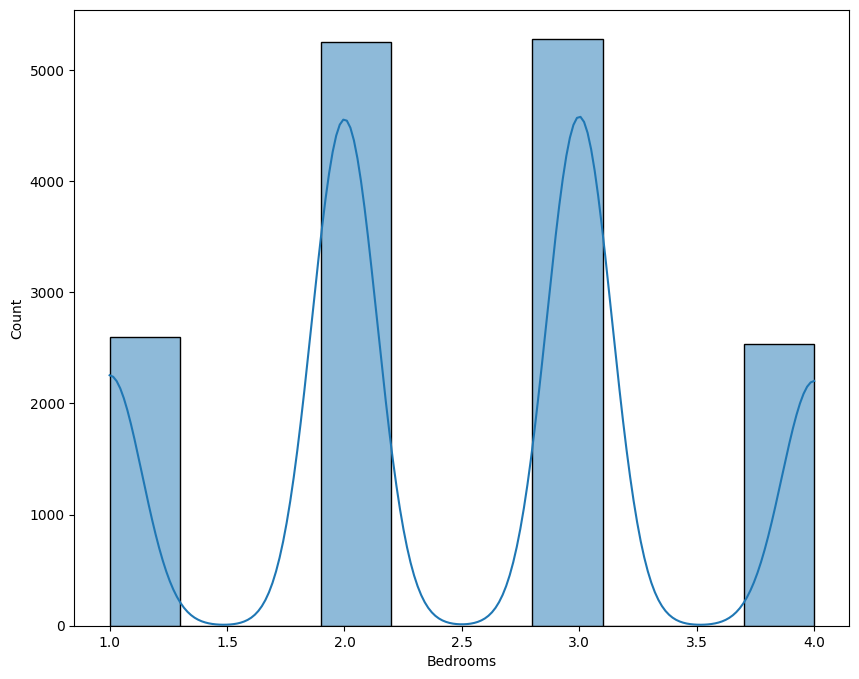

In [198]:
plt.figure(figsize=(10,8))
sns.histplot(data['Bedrooms'].dropna(),kde=True,bins=10)

In [199]:
data['City'].unique()

array(['Bhubaneshwar', 'Cuttack', 'Bhubaneswar', 'Puri', 'BBSR',
       'Khordha'], dtype=object)

In [200]:
data['City'] = data['City'].replace('Bhubaneshwar','Bhubaneswar').replace('BBSR','Bhubaneswar')

In [201]:
data

,HouseID,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,Property_Type,Furnished,Floor_No,Total_Floors,Latitude,Longitude,Loan_Status,Registration_Price,Day,Month,Sold_Year
0,H5239,2020-02-21,Bhubaneswar,1503.0,1,4,Yes,1981,5.7M,Flat,N,Ground,5,20.3094,85.5065,Approved,13712835,21,2,2020
1,H2788,2020-11-14,Bhubaneswar,918.0,3,1,No,2014,8350753,Apartment,No,2,2,20.3553,86.3665,Pending,6663623,14,11,2020
2,H5208,2020-11-29,Bhubaneswar,1358.0,2,2,N,1995,9.8M,Apartment,Y,3,5,19.5662,86.4131,Rejected,14044602,29,11,2020
3,H1742,2022-03-21,Cuttack,1085.0,3,4,N,2028,5679591,Flat,N,Ground,2,19.8848,86.0959,Pending,10877065,21,3,2022
4,H4533,2023-10-25,Bhubaneswar,3292.0,1,3,No,2028,2054447,APT,No,1,6,20.2625,86.0394,Rejected,2009594,25,10,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15649,H2162,2022-12-07,Puri,2004.0,2,3,Yes,2018,9.1M,APT,No,3,5,20.4786,85.5982,Pending,3388721,7,12,2022
15650,H4306,2021-11-01,Bhubaneswar,2950.0,4,4,No,2028,12639088,Apartment,Yes,1,10,20.2159,86.4082,Rejected,10676143,1,11,2021
15651,H4935,2022-04-30,Puri,2377.0,2,1,YES,2028,6806979,Villa,No,2,10,20.2710,86.3315,Pending,7258609,30,4,2022
15652,H1478,2020-04-02,Bhubaneswar,980.0,1,3,Y,1993,14.4M,Villa,No,2,6,20.1363,86.0574,Approved,7512664,2,4,2020


In [202]:
# plt.figure(figsize=(10,8))
# sns.histplot(data['City'].dropna(),kde=True,bins=10)

In [203]:
data['Garage'].unique()

array(['Yes', 'No', 'N', 'YES', 'Y'], dtype=object)

In [204]:
data['Garage'] = data['Garage'].replace('Yes','Y').replace('No','N').replace('YES','Y')

In [205]:
data

,HouseID,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,Property_Type,Furnished,Floor_No,Total_Floors,Latitude,Longitude,Loan_Status,Registration_Price,Day,Month,Sold_Year
0,H5239,2020-02-21,Bhubaneswar,1503.0,1,4,Y,1981,5.7M,Flat,N,Ground,5,20.3094,85.5065,Approved,13712835,21,2,2020
1,H2788,2020-11-14,Bhubaneswar,918.0,3,1,N,2014,8350753,Apartment,No,2,2,20.3553,86.3665,Pending,6663623,14,11,2020
2,H5208,2020-11-29,Bhubaneswar,1358.0,2,2,N,1995,9.8M,Apartment,Y,3,5,19.5662,86.4131,Rejected,14044602,29,11,2020
3,H1742,2022-03-21,Cuttack,1085.0,3,4,N,2028,5679591,Flat,N,Ground,2,19.8848,86.0959,Pending,10877065,21,3,2022
4,H4533,2023-10-25,Bhubaneswar,3292.0,1,3,N,2028,2054447,APT,No,1,6,20.2625,86.0394,Rejected,2009594,25,10,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15649,H2162,2022-12-07,Puri,2004.0,2,3,Y,2018,9.1M,APT,No,3,5,20.4786,85.5982,Pending,3388721,7,12,2022
15650,H4306,2021-11-01,Bhubaneswar,2950.0,4,4,N,2028,12639088,Apartment,Yes,1,10,20.2159,86.4082,Rejected,10676143,1,11,2021
15651,H4935,2022-04-30,Puri,2377.0,2,1,Y,2028,6806979,Villa,No,2,10,20.2710,86.3315,Pending,7258609,30,4,2022
15652,H1478,2020-04-02,Bhubaneswar,980.0,1,3,Y,1993,14.4M,Villa,No,2,6,20.1363,86.0574,Approved,7512664,2,4,2020


In [206]:
data['Property_Type'].unique()

array(['Flat', 'Apartment', 'APT', 'House', 'Villa'], dtype=object)

In [207]:
data['Property_Type'] = data['Property_Type'].replace('APT','Apartment')
data

,HouseID,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,Property_Type,Furnished,Floor_No,Total_Floors,Latitude,Longitude,Loan_Status,Registration_Price,Day,Month,Sold_Year
0,H5239,2020-02-21,Bhubaneswar,1503.0,1,4,Y,1981,5.7M,Flat,N,Ground,5,20.3094,85.5065,Approved,13712835,21,2,2020
1,H2788,2020-11-14,Bhubaneswar,918.0,3,1,N,2014,8350753,Apartment,No,2,2,20.3553,86.3665,Pending,6663623,14,11,2020
2,H5208,2020-11-29,Bhubaneswar,1358.0,2,2,N,1995,9.8M,Apartment,Y,3,5,19.5662,86.4131,Rejected,14044602,29,11,2020
3,H1742,2022-03-21,Cuttack,1085.0,3,4,N,2028,5679591,Flat,N,Ground,2,19.8848,86.0959,Pending,10877065,21,3,2022
4,H4533,2023-10-25,Bhubaneswar,3292.0,1,3,N,2028,2054447,Apartment,No,1,6,20.2625,86.0394,Rejected,2009594,25,10,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15649,H2162,2022-12-07,Puri,2004.0,2,3,Y,2018,9.1M,Apartment,No,3,5,20.4786,85.5982,Pending,3388721,7,12,2022
15650,H4306,2021-11-01,Bhubaneswar,2950.0,4,4,N,2028,12639088,Apartment,Yes,1,10,20.2159,86.4082,Rejected,10676143,1,11,2021
15651,H4935,2022-04-30,Puri,2377.0,2,1,Y,2028,6806979,Villa,No,2,10,20.2710,86.3315,Pending,7258609,30,4,2022
15652,H1478,2020-04-02,Bhubaneswar,980.0,1,3,Y,1993,14.4M,Villa,No,2,6,20.1363,86.0574,Approved,7512664,2,4,2020


In [208]:
data['Furnished'].unique()

array(['N', 'No', 'Y', 'Yes'], dtype=object)

In [209]:
data['Furnished'] = data['Furnished'].replace('Yes','Y').replace('No','N').replace('YES','Y')

In [210]:
data

,HouseID,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,Property_Type,Furnished,Floor_No,Total_Floors,Latitude,Longitude,Loan_Status,Registration_Price,Day,Month,Sold_Year
0,H5239,2020-02-21,Bhubaneswar,1503.0,1,4,Y,1981,5.7M,Flat,N,Ground,5,20.3094,85.5065,Approved,13712835,21,2,2020
1,H2788,2020-11-14,Bhubaneswar,918.0,3,1,N,2014,8350753,Apartment,N,2,2,20.3553,86.3665,Pending,6663623,14,11,2020
2,H5208,2020-11-29,Bhubaneswar,1358.0,2,2,N,1995,9.8M,Apartment,Y,3,5,19.5662,86.4131,Rejected,14044602,29,11,2020
3,H1742,2022-03-21,Cuttack,1085.0,3,4,N,2028,5679591,Flat,N,Ground,2,19.8848,86.0959,Pending,10877065,21,3,2022
4,H4533,2023-10-25,Bhubaneswar,3292.0,1,3,N,2028,2054447,Apartment,N,1,6,20.2625,86.0394,Rejected,2009594,25,10,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15649,H2162,2022-12-07,Puri,2004.0,2,3,Y,2018,9.1M,Apartment,N,3,5,20.4786,85.5982,Pending,3388721,7,12,2022
15650,H4306,2021-11-01,Bhubaneswar,2950.0,4,4,N,2028,12639088,Apartment,Y,1,10,20.2159,86.4082,Rejected,10676143,1,11,2021
15651,H4935,2022-04-30,Puri,2377.0,2,1,Y,2028,6806979,Villa,N,2,10,20.2710,86.3315,Pending,7258609,30,4,2022
15652,H1478,2020-04-02,Bhubaneswar,980.0,1,3,Y,1993,14.4M,Villa,N,2,6,20.1363,86.0574,Approved,7512664,2,4,2020


In [211]:
data['Floor_No'].unique()

array(['Ground', '2', '3', '1', 'G', '0'], dtype=object)

In [212]:
data['Floor_No'] = data['Floor_No'].replace('Ground','0').replace('G','0')

In [213]:
data['Floor_No'] = data['Floor_No'].astype(int)
data

,HouseID,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,Property_Type,Furnished,Floor_No,Total_Floors,Latitude,Longitude,Loan_Status,Registration_Price,Day,Month,Sold_Year
0,H5239,2020-02-21,Bhubaneswar,1503.0,1,4,Y,1981,5.7M,Flat,N,0,5,20.3094,85.5065,Approved,13712835,21,2,2020
1,H2788,2020-11-14,Bhubaneswar,918.0,3,1,N,2014,8350753,Apartment,N,2,2,20.3553,86.3665,Pending,6663623,14,11,2020
2,H5208,2020-11-29,Bhubaneswar,1358.0,2,2,N,1995,9.8M,Apartment,Y,3,5,19.5662,86.4131,Rejected,14044602,29,11,2020
3,H1742,2022-03-21,Cuttack,1085.0,3,4,N,2028,5679591,Flat,N,0,2,19.8848,86.0959,Pending,10877065,21,3,2022
4,H4533,2023-10-25,Bhubaneswar,3292.0,1,3,N,2028,2054447,Apartment,N,1,6,20.2625,86.0394,Rejected,2009594,25,10,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15649,H2162,2022-12-07,Puri,2004.0,2,3,Y,2018,9.1M,Apartment,N,3,5,20.4786,85.5982,Pending,3388721,7,12,2022
15650,H4306,2021-11-01,Bhubaneswar,2950.0,4,4,N,2028,12639088,Apartment,Y,1,10,20.2159,86.4082,Rejected,10676143,1,11,2021
15651,H4935,2022-04-30,Puri,2377.0,2,1,Y,2028,6806979,Villa,N,2,10,20.2710,86.3315,Pending,7258609,30,4,2022
15652,H1478,2020-04-02,Bhubaneswar,980.0,1,3,Y,1993,14.4M,Villa,N,2,6,20.1363,86.0574,Approved,7512664,2,4,2020


In [214]:
data['Price'].unique()

array(['5.7M', '8350753', '9.8M', ..., '12639088', '6806979', '6474127'],
      dtype=object)

In [215]:
def convert_price(x):
    if isinstance(x,str) and 'M' in x:
        return float(x.replace('M',''))*1_000_000
    else:
        return float(x)

In [216]:
data['Price'] = data['Price'].apply(convert_price)

In [217]:
data['Price'].isnull().sum()/len(data['Price'])*100

np.float64(0.4854989140155871)

In [218]:
data['Price'] = data['Price'].fillna(data['Price'].mean())

In [219]:
data

,HouseID,Date_Sold,City,Area_sqft,Bedrooms,Bathrooms,Garage,Year_Built,Price,Property_Type,Furnished,Floor_No,Total_Floors,Latitude,Longitude,Loan_Status,Registration_Price,Day,Month,Sold_Year
0,H5239,2020-02-21,Bhubaneswar,1503.0,1,4,Y,1981,5700000.0,Flat,N,0,5,20.3094,85.5065,Approved,13712835,21,2,2020
1,H2788,2020-11-14,Bhubaneswar,918.0,3,1,N,2014,8350753.0,Apartment,N,2,2,20.3553,86.3665,Pending,6663623,14,11,2020
2,H5208,2020-11-29,Bhubaneswar,1358.0,2,2,N,1995,9800000.0,Apartment,Y,3,5,19.5662,86.4131,Rejected,14044602,29,11,2020
3,H1742,2022-03-21,Cuttack,1085.0,3,4,N,2028,5679591.0,Flat,N,0,2,19.8848,86.0959,Pending,10877065,21,3,2022
4,H4533,2023-10-25,Bhubaneswar,3292.0,1,3,N,2028,2054447.0,Apartment,N,1,6,20.2625,86.0394,Rejected,2009594,25,10,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15649,H2162,2022-12-07,Puri,2004.0,2,3,Y,2018,9100000.0,Apartment,N,3,5,20.4786,85.5982,Pending,3388721,7,12,2022
15650,H4306,2021-11-01,Bhubaneswar,2950.0,4,4,N,2028,12639088.0,Apartment,Y,1,10,20.2159,86.4082,Rejected,10676143,1,11,2021
15651,H4935,2022-04-30,Puri,2377.0,2,1,Y,2028,6806979.0,Villa,N,2,10,20.2710,86.3315,Pending,7258609,30,4,2022
15652,H1478,2020-04-02,Bhubaneswar,980.0,1,3,Y,1993,14400000.0,Villa,N,2,6,20.1363,86.0574,Approved,7512664,2,4,2020


In [220]:
categorical_cols = data.select_dtypes(include=['object']).columns
data.select_dtypes(include='object').columns

Index(['HouseID', 'City', 'Garage', 'Property_Type', 'Furnished',
       'Loan_Status'],
      dtype='object')

In [221]:
from sklearn.preprocessing import OrdinalEncoder

ordi = OrdinalEncoder(categories=[['Puri','Bhubaneswar','Cuttack','Khordha']])
data['City'] = ordi.fit_transform(data[['City']])

ordiLS = OrdinalEncoder(categories=[['Approved','Rejected','Pending']])
data['Loan_Status'] = ordiLS.fit_transform(data[['Loan_Status']])


In [222]:
from sklearn.preprocessing import LabelEncoder

le =LabelEncoder()
data['Garage'] = le.fit_transform(data['Garage'])
data['Furnished'] = le.fit_transform(data['Furnished'])

In [225]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)
data = pd.get_dummies(data,columns=['Property_Type'])
